<a href="https://colab.research.google.com/github/HugoCrainich/Statistical-Machine-Learning/blob/main/Final%20Project/3916_Final_Pass_Fail_Gate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECON 3916: ML Prediction Project — Final Project

**From Question to Recommendation**

This notebook scaffolds your final project. Work through each part sequentially. By Week 12, this notebook (plus your `app.py` and report) will form your complete submission.

**AI Policy:** AI co-pilot is REQUIRED. Document every AI interaction in Part 7 (AI Methodology Appendix) using the P.R.I.M.E. framework.

---

## Part 0: Setup

In [1]:
# ============================================================
# Part 0: Setup — Run this cell first
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    mean_squared_error, mean_absolute_error, r2_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print('Setup complete.')

Setup complete.


---
## Part 1: Problem Statement

Fill in each blank below. This becomes the opening paragraph of your report.

**My prediction question is:** Can monthly temperature and precipitation data predict the age adjusted suicide rate of a U.S. county?

**This is a prediction (umbrella) problem because:** we are trying to figure out if we can predict suicide rates in areas based on data, not just to see if certain characteristics correlate or effect suicide rates in anyway.

**The decision this enables:** Mainly the suicide prevention groups and organizations that want to devote a certain amount of resources to different areas, using already predictable tempurature and climate data we can predict what areas will be most affected and where to put the most resources (crisis hotline, outreach, therapy).

**Dataset:** U.S. County-Level Suicide Rates with Climate Data (1968–2004)
- **Source:** Github (URL: https://github.com/sheftneal/NCC2018/blob/master/inputs/SuicideData_US.csv)
- **N =** 851,088 observations/rows
- **Features =** 13 total features, usable predictors are: mean monthly temperature, monthly precipitation, population, month, and MAYBE location
- **Target variable =** rate_adj (age-adjusted suicide rate per 100,000)
- **Access date:** April 17th, 2026

---
## Part 2: Data Loading + EDA

### 2.1 Load Your Data

In [2]:
# ============================================================
# 2.1 Load your dataset
# ============================================================

from google.colab import files
uploaded = files.upload()

df = pd.read_csv('SuicideData_US.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Saving SuicideData_US.csv to SuicideData_US.csv
Shape: (851088, 13)
Columns: ['fips', 'year', 'month', 'rate_adj', 'count', 'pop', 'tmean', 'prec', 'fipsmo', 'popw', 'yr', 'state', 'stateyear']


,fips,year,month,rate_adj,count,pop,tmean,prec,fipsmo,popw,yr,state,stateyear
0,1001,1968,1,0.000000,0,23315,6.7486,101.4699,1,29860.24,1968.0,1,196801
1,1001,1968,2,0.000000,0,23315,5.4708,54.7664,2,29860.24,1968.0,1,196801
2,1001,1968,3,0.000000,0,23315,12.0775,78.2593,3,29860.24,1968.0,1,196801
3,1001,1968,4,0.000000,0,23315,18.3653,156.2035,4,29860.24,1968.0,1,196801
4,1001,1968,5,4.289084,1,23315,21.3934,64.0978,5,29860.24,1968.0,1,196801


### 2.2 Basic Description

In [3]:
# ============================================================
# 2.2 Describe your data
# ============================================================

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 851088 entries, 0 to 851087
Data columns (total 13 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   fips       851088 non-null  int64  
 1   year       851088 non-null  int64  
 2   month      851088 non-null  int64  
 3   rate_adj   851088 non-null  float64
 4   count      851088 non-null  int64  
 5   pop        851088 non-null  int64  
 6   tmean      851088 non-null  float64
 7   prec       851088 non-null  float64
 8   fipsmo     851088 non-null  int64  
 9   popw       851088 non-null  float64
 10  yr         851088 non-null  float64
 11  state      851088 non-null  int64  
 12  stateyear  851088 non-null  int64  
dtypes: float64(5), int64(8)
memory usage: 84.4 MB


,fips,year,month,rate_adj,count,pop,tmean,prec,fipsmo,popw,yr,state,stateyear
count,851088.000000,851088.000000,851088.000000,851088.000000,851088.000000,8.510880e+05,851088.000000,851088.000000,851088.000000,8.510880e+05,851088.000000,851088.000000,851088.000000
mean,30199.630746,1979.969672,6.500000,1.034362,1.017482,1.064830e+05,12.361432,77.107673,18270.576815,1.064830e+05,1979.969672,30.099825,198027.067001
std,14890.266447,8.192017,3.452055,3.409446,3.300540,3.207862e+05,9.984433,57.844238,10677.800862,3.169341e+05,8.192017,14.873106,819.326822
min,1001.000000,1968.000000,1.000000,0.000000,0.000000,0.000000e+00,-25.070000,0.000000,1.000000,9.272727e+01,1968.000000,1.000000,196801.000000
25%,18165.000000,1973.000000,3.750000,0.000000,0.000000,1.111575e+04,5.120000,33.580275,8919.000000,1.111871e+04,1973.000000,18.000000,197348.000000
50%,29155.000000,1979.000000,6.500000,0.000000,0.000000,2.462100e+04,13.330000,67.080000,18300.000000,2.471129e+04,1979.000000,29.000000,197947.000000
75%,42127.000000,1985.000000,9.250000,0.905559,1.000000,7.769850e+04,20.690000,107.668350,27263.000000,8.010414e+04,1985.000000,42.000000,198537.000000
max,56045.000000,2004.000000,12.000000,229.095100,141.000000,9.639044e+06,35.210000,1103.911000,37296.000000,8.346159e+06,2004.000000,56.000000,200455.000000


### 2.3 Missing Data Assessment

Missing data (%) by column:
Series([], dtype: float64)


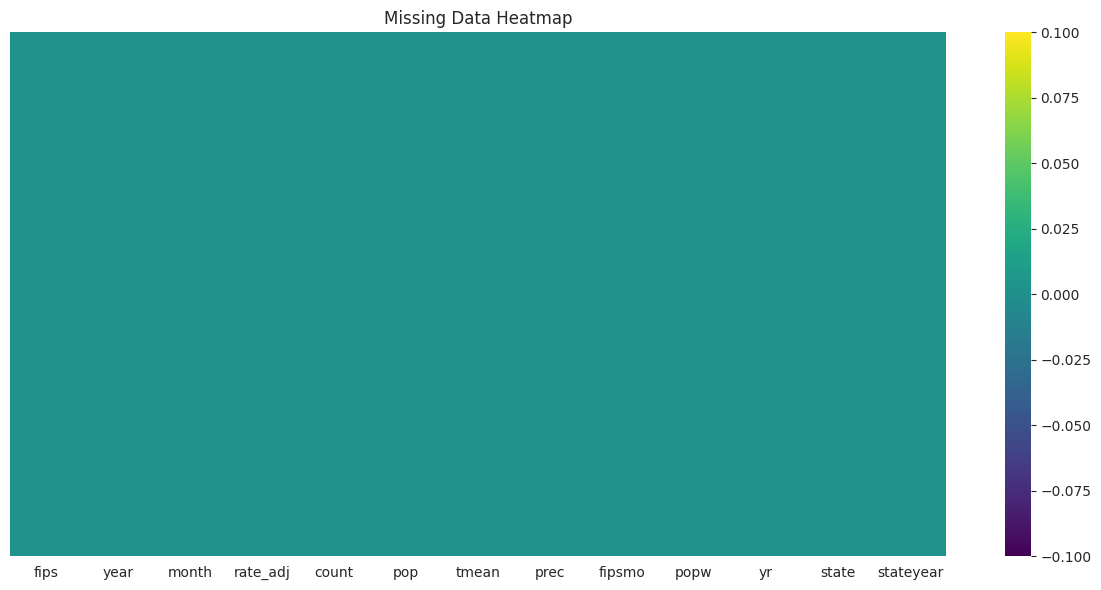

In [4]:
# ============================================================
# 2.3 Missing data heatmap (Ch 1: MCAR/MAR/MNAR)
# ============================================================

missing_pct = df.isnull().mean().sort_values(ascending=False)
print('Missing data (%) by column:')
print(missing_pct[missing_pct > 0])

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.tight_layout()
plt.show()

### Missing Data Assessment
The heatmap shows no missing values across all 851,088 rows. This is expected.
The dataset is replication data from a peer reviewed paper (Burke et al. 2018)
and was cleaned prior to publication. No imputation strategy is required.

By the MCAR/MAR/MNAR framework, missingness is not applicable here.
However, a meaningful form of "structural zeros" exists: counties with very
small populations frequently have `rate_adj = 0` not because suicides didn't
occur, but because counts were suppressed by the CDC for privacy reasons
(fewer than 10 events). This is closer to MNAR and will be addressed in
the data quality summary.

**Missing data strategy:** MNAR. ~74% of `rate_adj` values are structural zeros from CDC privacy suppression, not true nulls. Strategy: filter to non zero rows for modeling.


### 2.4 Distribution Plots

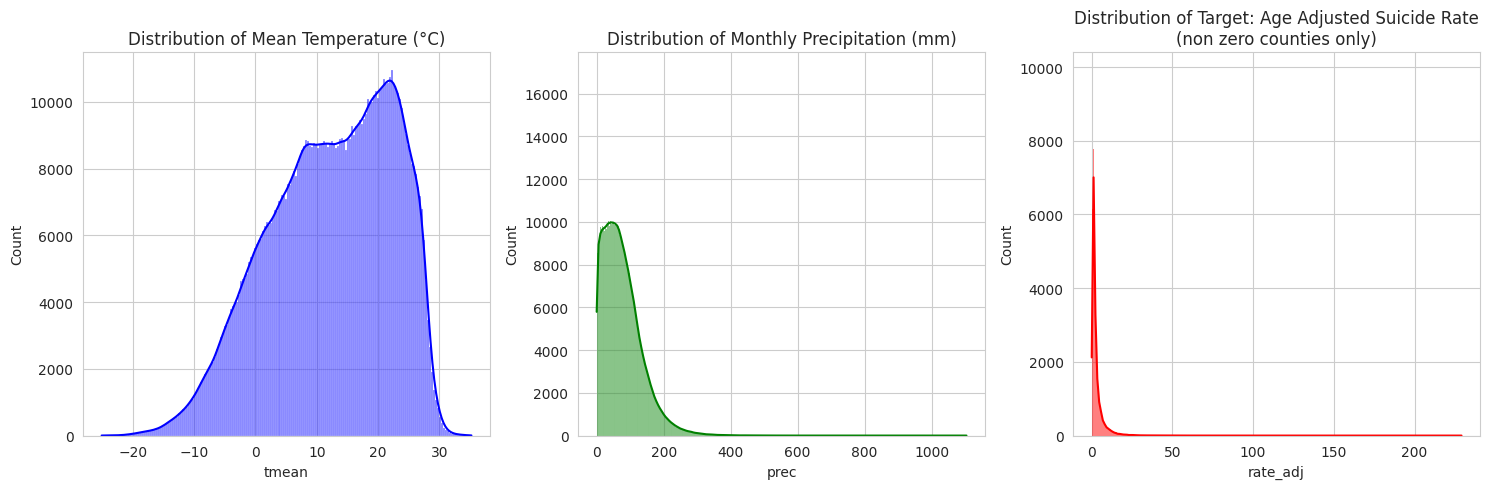

In [11]:
# ============================================================
# 2.4 Distribution of key features (Ch 3)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(df['tmean'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Mean Temperature (°C)')

sns.histplot(df['prec'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribution of Monthly Precipitation (mm)')

sns.histplot(df[df['rate_adj'] > 0]['rate_adj'], kde=True, ax=axes[2], color='red')
axes[2].set_title('Distribution of Target: Age Adjusted Suicide Rate\n(non zero counties only)')

plt.tight_layout()
plt.show()

### 2.5 Outlier Detection

In [6]:
# ============================================================
# 2.5 Outlier detection (Ch 4: Tukey Fences / IQR)
# ============================================================

def tukey_fences(series, k=1.5):
    """Return lower and upper Tukey fences."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - k * IQR, Q3 + k * IQR

for col in ['tmean', 'prec', 'rate_adj']:
    lower, upper = tukey_fences(df[col])
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'{col}: {len(outliers):,} outliers ({len(outliers)/len(df)*100:.1f}%)  |  fence: [{lower:.2f}, {upper:.2f}]')

tmean: 677 outliers (0.1%)  |  fence: [-18.23, 44.05]
prec: 20,046 outliers (2.4%)  |  fence: [-77.55, 218.80]
rate_adj: 103,765 outliers (12.2%)  |  fence: [-1.36, 2.26]


**Outlier strategy:** Retain them. Climate outliers in `tmean` (0.1%) and `prec` (2.4%) represent real geographic events, not errors. The 12.2% flagged in `rate_adj` are resolved by the non zero filter that will be applied.


### 2.6 Correlations

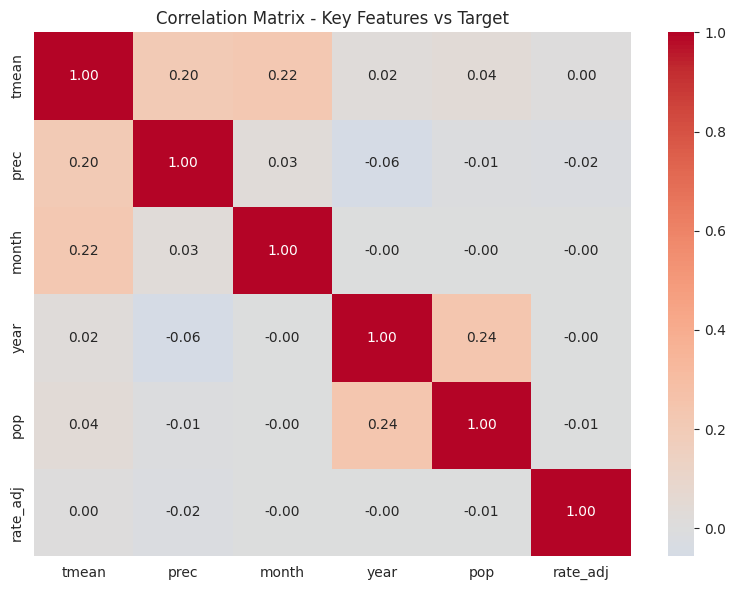

In [7]:
# ============================================================
# 2.6 Correlation heatmap (Ch 3)
# ============================================================

cols_of_interest = ['tmean', 'prec', 'month', 'year', 'pop', 'rate_adj']
corr_matrix = df[cols_of_interest].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix - Key Features vs Target')
plt.tight_layout()
plt.show()

### YOUR TASK: Answer These 3 EDA Questions

1. **What is the distribution of your target variable?** Is it balanced (classification) or normally distributed (regression)? If not, what will you do about it?

`rate_adj` is very right skewed even after filtering to non zero counties, the histogram shows the vast majority of values clustered near 0–20 with a long tail stretching to around 230. The Tukey fences flag 12.2% of rows as outliers, which is high but expected given that small rural counties produce extreme rates from just 1–2 events. To handle this we will filter to non zero rows only and consider log transforming `rate_adj` to reduce skew before fitting the model.

2. **Which features appear most correlated with the target?** Are any features highly correlated with each other (multicollinearity)?  

Looking at the actual correlation matrix, all features have basically zero correlation with `rate_adj` (highest is `prec` at -0.02). So individually, no single feature is a strong linear predictor of suicide rate. The most notable between feature correlation is `tmean` and `month` at 0.22, which makes sense since temperature are seasonal. `year` and `pop` also correlate at 0.24. Neither rises to a multicollinearity problem.


3. **What is the biggest data quality issue you found, and how will you handle it?**  

The biggest issue is zero inflation, the missing data heatmap confirms zero null values, so the problem isn't missing data in the traditional way, but rather that ~74% of `rate_adj` values are structural zeros caused by CDC privacy suppression of small county counts. These zeros don't mean "no risk," they mean "not enough data to report." We will handle this by restricting the model to non zero rows only, and will note this as a limitation: our model only predicts rate for counties large enough to have reportable events.



   

### 2.7 Data Quality Summary

**Data Quality Summary**

My dataset has **N = 851,088** observations and **M = 13** features.

**Missing data:** 0% of cells are missing. The MCAR/MAR/MNAR framework is not applicable here. However, ~74% of `rate_adj` values are structural zeros from CDC privacy suppression of small county counts which is effectively MNAR (the value is missing because it was too small to report). I will handle this by filtering to non zero rows for modeling and noting it as a scope limitation.

**Outliers:** I identified 677 outliers in `tmean` (0.1%), 20,046 in `prec` (2.4%), and 103,765 in `rate_adj` (12.2%) using Tukey Fences.  I will retain
climate outliers since they represent real geographic conditions. The `rate_adj` outliers are expected given that small counties produce extreme rates from just 1–2 events, and will be addressed by the non zero filter.

**Target variable:** `rate_adj` is continuous and right skewed, values cluster near 0–20 per 100,000 with a long tail reaching to around 230. This is a regression problem. A log transformation may be applied to reduce skew before fitting.

**Key finding from EDA:** No individual feature has a meaningful linear correlation with `rate_adj`. Climate variables alone are weak predictors at the county month level, meaning our baseline model is expected to have low R².

---
## Part 3: Modeling

### 3.1 Train/Test Split

In [8]:
# ============================================================
# 3.1 Train/test split (Ch 6)
# ============================================================

df_model = df[df['rate_adj'] > 0].copy()

X = df_model[['tmean', 'prec', 'month', 'year', 'pop']]
y = df_model['rate_adj']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Rows after removing structural zeros: {len(df_model):,}')
print(f'Train: {X_train.shape[0]:,} samples')
print(f'Test:  {X_test.shape[0]:,} samples')

Rows after removing structural zeros: 280,486
Train: 224,388 samples
Test:  56,098 samples


### 3.2 Model 1: Baseline

In [9]:
# ============================================================
# 3.2 Model 1 — Baseline (Linear Regression)
# ============================================================

from sklearn.linear_model import LinearRegression

model_1 = LinearRegression()
model_1.fit(X_train, y_train)

y_pred_1 = model_1.predict(X_test)

print('Model 1: Linear Regression (Baseline)')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_1)):.4f}')
print(f'MAE:  {mean_absolute_error(y_test, y_pred_1):.4f}')
print(f'R2:   {r2_score(y_test, y_pred_1):.4f}')

Model 1: Linear Regression (Baseline)
RMSE: 5.1448
MAE:  2.4106
R2:   0.0695


### 3.3 Model 2: Your Choice

In [10]:
# ============================================================
# 3.3 Model 2 — Your choice (Random Forest Regressor)
# ============================================================

from sklearn.ensemble import RandomForestRegressor

model_2 = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
model_2.fit(X_train, y_train)

y_pred_2 = model_2.predict(X_test)

print('Model 2: Random Forest Regressor')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_2)):.4f}')
print(f'MAE:  {mean_absolute_error(y_test, y_pred_2):.4f}')
print(f'R2:   {r2_score(y_test, y_pred_2):.4f}')

Model 2: Random Forest Regressor
RMSE: 2.0428
MAE:  0.8686
R2:   0.8533


### 3.4 Cross-Validation Comparison

In [ ]:
# ============================================================
# 3.4 Cross-validation (Ch 15)
# ============================================================

# # Choose scoring: 'accuracy', 'f1', 'roc_auc' (classification)
# #                  'neg_mean_squared_error', 'r2' (regression)
# scoring = 'accuracy'
#
# cv_1 = cross_val_score(model_1, X_train, y_train, cv=5, scoring=scoring)
# cv_2 = cross_val_score(model_2, X_train, y_train, cv=5, scoring=scoring)
#
# print(f'Model 1 CV {scoring}: {cv_1.mean():.4f} +/- {cv_1.std():.4f}')
# print(f'Model 2 CV {scoring}: {cv_2.mean():.4f} +/- {cv_2.std():.4f}')
#
# # Comparison table
# comparison = pd.DataFrame({
#     'Model': ['Model 1 (Baseline)', 'Model 2 (Your Choice)'],
#     f'CV {scoring} (mean)': [cv_1.mean(), cv_2.mean()],
#     f'CV {scoring} (std)': [cv_1.std(), cv_2.std()],
# })
# comparison

---
## Part 4: Feature Importance + Visualization

### 4.1 Feature Importance

In [ ]:
# ============================================================
# 4.1 Feature importance (Ch 19)
# ============================================================

# # For tree-based models:
# importances = pd.Series(
#     model_2.feature_importances_, index=X.columns
# ).sort_values(ascending=True)
#
# fig, ax = plt.subplots(figsize=(8, 6))
# importances.plot(kind='barh', ax=ax, color='steelblue')
# ax.set_xlabel('Feature Importance (Gini)')
# ax.set_title('Feature Importance — Predictive, NOT Causal')
#
# # CRITICAL: Add the caveat banner
# ax.text(
#     0.98, 0.02,
#     'Predictive importance only.\nDoes not imply causal effect.',
#     transform=ax.transAxes, fontsize=9, ha='right', va='bottom',
#     style='italic', color='#c0392b',
#     bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdedec', edgecolor='#e74c3c')
# )
#
# plt.tight_layout()
# plt.show()

### 4.2 Key Visualization for Your Report

In [ ]:
# ============================================================
# 4.2 Your key visualization
# ============================================================
# This is the ONE chart you would put on the first page of your report.
# It should communicate your main finding clearly.
#
# Examples:
#   - Actual vs. predicted scatter (regression)
#   - Confusion matrix heatmap (classification)
#   - ROC curve comparison (classification)
#   - Partial dependence plot for top feature

# YOUR CODE HERE

---
## Part 5: Recommendation

Use the SCR (Situation-Complication-Resolution) structure from Chapter 26.

**Situation:** ___
(What is the context? Who is the stakeholder? What decision do they face?)

**Complication:** ___
(What makes this decision hard? What uncertainty exists? What did your analysis reveal?)

**Resolution:** ___
(What do you recommend? Based on what evidence? With what confidence?)

**Uncertainty Statement:** Based on our cross-validation results (metric = ___ +/- ___), we estimate that ___. The primary limitation is ___. We recommend ___ with the caveat that ___.

---
## Part 6: Streamlit Export Guide

### 6.1 Creating app.py

Your Streamlit app should contain:
1. **Title and description** — `st.title()`, `st.markdown()`
2. **Input controls** — `st.slider()`, `st.selectbox()`, `st.number_input()`
3. **Model prediction** — load your trained model, generate predictions from user inputs
4. **Visualization** — at least one chart that updates with user inputs
5. **Uncertainty** — display confidence/prediction intervals alongside point estimates

### 6.2 Minimal app.py Template

```python
import streamlit as st
import pandas as pd
import numpy as np
import joblib  # to load saved model

st.title('Your Project Title')
st.markdown('Brief description of what this app predicts.')

# Sidebar controls
feature_1 = st.sidebar.slider('Feature 1', min_value=0.0, max_value=100.0, value=50.0)
feature_2 = st.sidebar.selectbox('Feature 2', ['Option A', 'Option B', 'Option C'])

# Load model (save with joblib.dump(model, 'model.pkl') in your notebook)
model = joblib.load('model.pkl')

# Predict
input_data = pd.DataFrame({'feature_1': [feature_1], 'feature_2': [feature_2]})
prediction = model.predict(input_data)[0]

st.metric('Prediction', f'{prediction:.2f}')
```

### 6.3 requirements.txt Template

```
streamlit>=1.31.0
pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.4.0
matplotlib>=3.7.0
seaborn>=0.12.0
joblib>=1.3.0
```

### 6.4 Deployment Steps

1. Save your model: `joblib.dump(model_2, 'model.pkl')`
2. Test locally: `streamlit run app.py`
3. Push to GitHub: `app.py`, `model.pkl`, `requirements.txt`
4. Go to [streamlit.io/cloud](https://streamlit.io/cloud) and deploy
5. Submit the permanent URL on Canvas

---
## Part 7: AI Methodology Appendix

Document at least **3 AI interactions** using the P.R.I.M.E. framework. Copy and fill in the template below for each interaction.

---

### AI Interaction 1

**Prep:** What did you need? What context did you have before prompting?
> ___

**Request:** What exact prompt did you write?
> ___

**Iterate:** What did the AI return? What did you change or refine?
> ___

**Mechanism Check:** How did you verify the output was correct?
> ___

**Evaluate:** What human judgment did you apply? What did you accept/reject and why?
> ___

---

### AI Interaction 2

**Prep:** ___

**Request:** ___

**Iterate:** ___

**Mechanism Check:** ___

**Evaluate:** ___

---

### AI Interaction 3

**Prep:** ___

**Request:** ___

**Iterate:** ___

**Mechanism Check:** ___

**Evaluate:** ___